In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

/home/ozahn/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
train_preds = pd.read_excel('/home/ozahn/astmh/LLMForASTMH/results/088dva8c/train_predictions.xlsx')
val_preds = pd.read_excel('/home/ozahn/astmh/LLMForASTMH/results/088dva8c/val_predictions.xlsx')

In [3]:
def create51ClassConfusionMatrix_fn(trueLabel, pred, testTrueLabel=[], testPred=[], titleStr=''):
    """
    Plot a confusion matrix for 51 fine-grained categories. Plot jittered points rather than numbers,
    with the important categories outlined in red.
    If 'testPred' is NOT empty, train and test set results are plotted in different colors.
    This function does not save the figure to PNG (no particular reason).
    CAUTION: the 'trueLabels' and 'pred' are alphabetical over the 51 merged categories as
    follows. The plot formatting depends on this.

    0 : Arthropods/Entomology - Other
    1 : Bacteriology - Enteric Infections
    2 : Bacteriology - Other Bacterial Infections
    3 : Bacteriology - Systemic Infections
    4 : Cestodes
    5 : Clinical Tropical Medicine
    6 : Ectoparasite-Borne Disease - All
    7 : Global Health - Diversity, Inclusion, Decolonization and Human Rights
    8 : Global Health - Information/Communication/Technologies
    9 : Global Health - Other
    10 : Global Health - Planetary Health including Climate Change
    11 : Global Health - Security/Preparedness
    12 : HIV and Tropical Co-Infections
    13 : Helminths - Nematodes - Filariasis (Epidemiology and Modeling)
    14 : Helminths - Nematodes - Filariasis (Molecular Biology and Immunology)
    15 : Helminths - Nematodes - Filariasis (Other)
    16 : Helminths - Nematodes - Intestinal Nematodes
    17 : Integrated Control Measures for Neglected Tropical Diseases (NTDs)
    18 : Kinetoplastida - All
    19 : Malaria - Antimalarial Resistance and Chemotherapy
    20 : Malaria - Diagnosis - Challenges and Innovations
    21 : Malaria - Drug Development and Clinical Trials
    22 : Malaria - Elimination
    23 : Malaria - Epidemiology
    24 : Malaria - Genetics, Genomics and Evolution
    25 : Malaria - Immunology
    26 : Malaria - Parasite Transmission Biology
    27 : Malaria - Pathogenesis
    28 : Malaria - Prevention
    29 : Malaria - Surveillance and Data Utilization
    30 : Malaria - Vaccines and Immunotherapeutics
    31 : Mosquitoes - Biology and Genetics of Insecticide Resistance
    32 : Mosquitoes - Biology, Physiology and Immunity
    33 : Mosquitoes - Bionomics, Behavior and Surveillance
    34 : Mosquitoes - Epidemiology and Vector Control
    35 : Mosquitoes - Molecular Biology, Population Genetics and Genomics
    36 : One Health: Interconnections
    37 : Pneumonia, Respiratory Infections and Tuberculosis
    38 : Schistosomiasis and Other Trematodes - Diagnostics and Treatment
    39 : Schistosomiasis and Other Trematodes - Epidemiology and Control
    40 : Schistosomiasis and Other Trematodes - Immunology Etc
    41 : Viruses - Emerging Viral Diseases
    42 : Viruses - Epidemiology
    43 : Viruses - Evolution and Genomic Epidemiology
    44 : Viruses - Field and ecological studies of viruses
    45 : Viruses - Immunology
    46 : Viruses - Pathogenesis and Animal Models
    47 : Viruses - Therapeutics and Antiviral Drugs
    48 : Viruses - Transmission Biology
    49 : Viruses - Vaccine Clinical Trials
    50 : Water, Sanitation, Hygiene and Environmental Health

    Parameters
    ----------
    trueLabels : list-like of ints
    pred : list-like of ints
    testTrueLabel : list-like of ints
    testPred : list-like of ints

    Returns
    -------
    None.

    """
    plt.figure(figsize=(15,15))
    half = 0.4
    jitterX = -half + 2 *half *  np.random.random(len(pred))
    jitterY = -half + 2 * half * np.random.random(len(pred))
    jitterXTest = -half + 2 *half *  np.random.random(len(testPred))
    jitterYTest = -half + 2 * half * np.random.random(len(testPred))
    borders = np.array([0, 3,4,5, 6, 11, 15,16,17,18, 30, 35, 36, 37, 40, 49]) + 0.5
    importantBorders = np.array([6, 11, 18, 30, 35, 36]) + 0.5
    plt.hlines(borders, -0.5, 50.5, colors='g', linestyles=':')
    plt.vlines(borders, -0.5, 50.5, color='g', linestyle=':')
    plt.hlines(importantBorders, -0.5, 50.5, color='r')
    for i in range(0, len(importantBorders), 2):
        plt.vlines([importantBorders[i], importantBorders[i + 1]],
                   importantBorders[i], importantBorders[i + 1], color='r')
    plt.gca().set_aspect('equal')

    plt.plot(pred + jitterY, trueLabel + jitterX, 'b+')
    if len(testPred) > 0:
        plt.plot(testPred + jitterYTest, testTrueLabel + jitterXTest, 'r+')

    xTickLocations = [0,2, 4,5,6,9,13.5, 16,17,18,25,33,36,37,39,44,50]
    xTickLabels = ['arthropods', 'bacteria', 'cestodes', 'clin trop med', 'ectoparasite',
                   'global health', 'helminths', 'HIV', 'integrated', 'kinetoplastida',
                   'malaria', 'mosquitoes', 'one health', 'pneumonia', 'schisto',
                   'viruses', 'sanitation']
    plt.yticks( xTickLocations, xTickLabels)
    plt.xticks( xTickLocations, xTickLabels, rotation='vertical')

    endStr = '.'
    if len(testPred) > 0:
        endStr = '. train = blue, test = red'
    plt.title('Predictions vs true class, ASTMH, ' + titleStr + endStr,
              fontweight='bold')
    plt.xlabel('true labels', fontweight='bold')
    plt.ylabel('predicted', fontweight='bold')
    plt.tight_layout()

In [4]:
def create17ClassConfusionMatrix_fn(trueLabel, pred, testTrueLabel, testPred, titleStr=''):
    """
    Plot a confusion matrix for 17 general categories. Plot jittered points rather than numbers,
    with the important categories outlined in red.
    Train and test set results are plotted in different colors.
    This function does not save the figure to PNG (no particular reason).
    CAUTION: the 'trueLabels' and 'pred' are alphabetical over the 17 short general categories as
    follows. The plot formatting depends on this.

    Short general categories:
    0 : Bacteriology
    1 : Cestodes
    2 : Clinical Trop Med
    3 : Ectoparasite-Borne
    4 : Entomology
    5 : Global Health
    6 : HIV
    7 : Helminths
    8 : Integrated Control
    9 : Kinetoplastida
    10 : Malaria
    11 : Mosquitoes
    12 : One Health
    13 : Pneumonia TB
    14 : Schistosomiasis
    15 : Viruses
    16 : Water Sanitation

    Parameters
    ----------
    trueLabel : list-like of ints
    pred : list-like of ints
    testTrueLabel : list-like of ints
    testPred : list-like of ints

    Returns
    -------
    None.

    """
    plt.figure(figsize=(15,15))
    half = 0.4
    jitterX = -half + 2 *half *  np.random.random(len(pred))
    jitterY = -half + 2 * half * np.random.random(len(pred))
    jitterXTest = -half + 2 *half *  np.random.random(len(testPred))
    jitterYTest = -half + 2 * half * np.random.random(len(testPred))
    borders = np.arange(0, 16) + 0.5
    importantBorders = np.array([4, 5, 7, 8, 9, 10]) + 0.5  # malaria, global health, integrated
    # control
    plt.hlines(borders, -0.5, 16.5, color='g', linestyle=':')
    plt.vlines(borders, -0.5, 16.5, color='g', linestyle=':')
    plt.hlines(importantBorders, -0.5, 16.5, color='r')
    for i in range(0, len(importantBorders), 2):
        plt.vlines([importantBorders[i], importantBorders[i + 1]],
                   importantBorders[i], importantBorders[i + 1], color='r')
    plt.gca().set_aspect('equal')
    plt.plot(pred + jitterY, trueLabel + jitterX, 'b*')
    plt.plot(testPred + jitterYTest, testTrueLabel + jitterXTest, 'r+')
    xTickLocations = np.arange(0, 17)
    xTickLabels = ['Bacteriology', 'Cestodes', 'Clinical Trop Med', 'Ectoparasite-Borne',
      'Entomology', 'Global Health', 'HIV', 'Helminths', 'Integrated Control', 'Kinetoplastida',
      'Malaria', 'Mosquitoes', 'One Health', 'Pneumonia TB', 'Schistosomiasis', 'Viruses',
      'Water Sanitation']
    plt.yticks( xTickLocations, xTickLabels)
    plt.xticks( xTickLocations, xTickLabels, rotation='vertical')
    plt.title('Predictions vs true class, ASTMH, ' + titleStr + '. train = blue, test = red',
              fontweight='bold')
    plt.xlabel('true labels', fontweight='bold')
    plt.ylabel('predicted', fontweight='bold')
    plt.tight_layout()

In [5]:
np.unique(train_preds['prediction'])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])

In [6]:
np.unique(val_preds['prediction'])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])

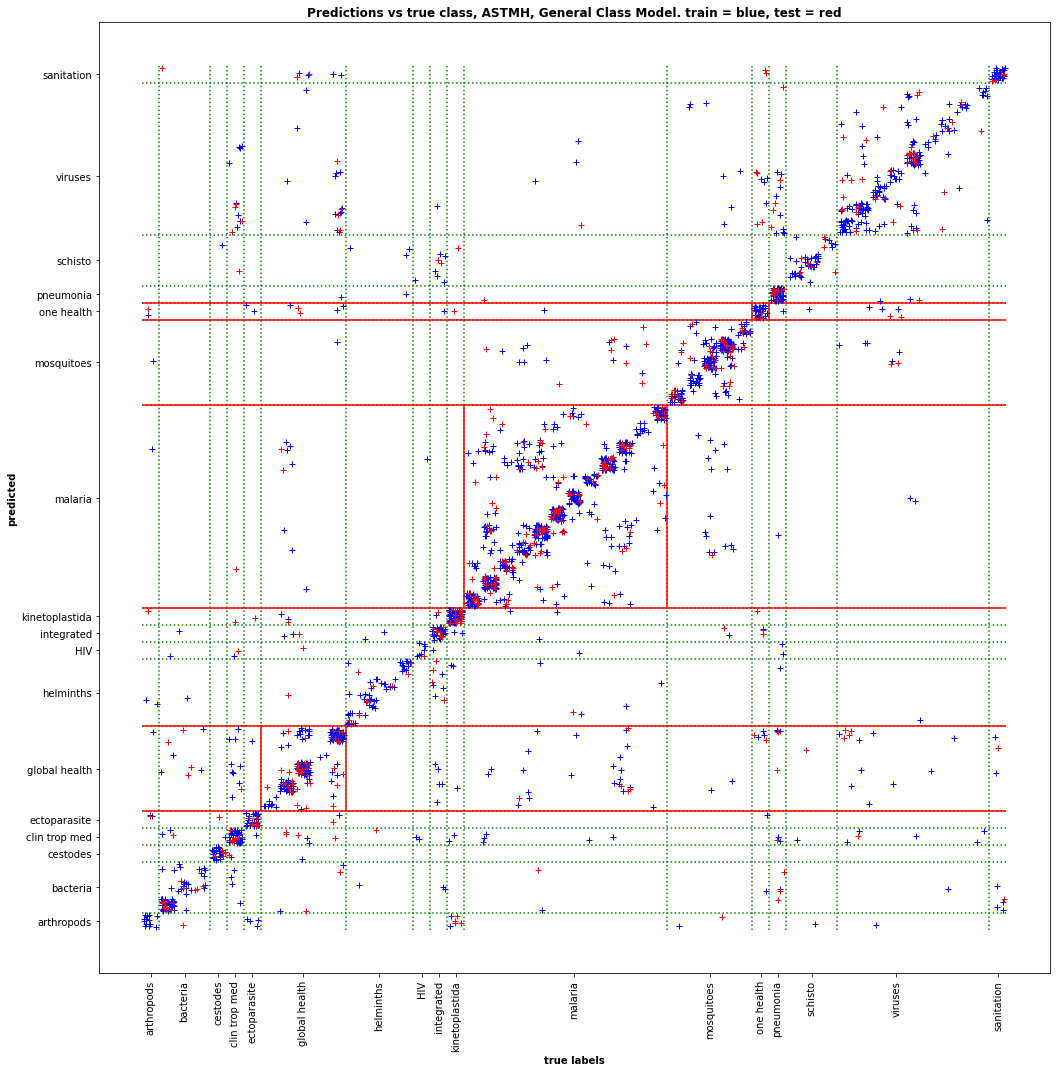

In [7]:
create51ClassConfusionMatrix_fn(train_preds['label'],
                                train_preds['prediction'],
                                val_preds['label'],
                                val_preds['prediction'],
                                titleStr='General Class Model'
                                )

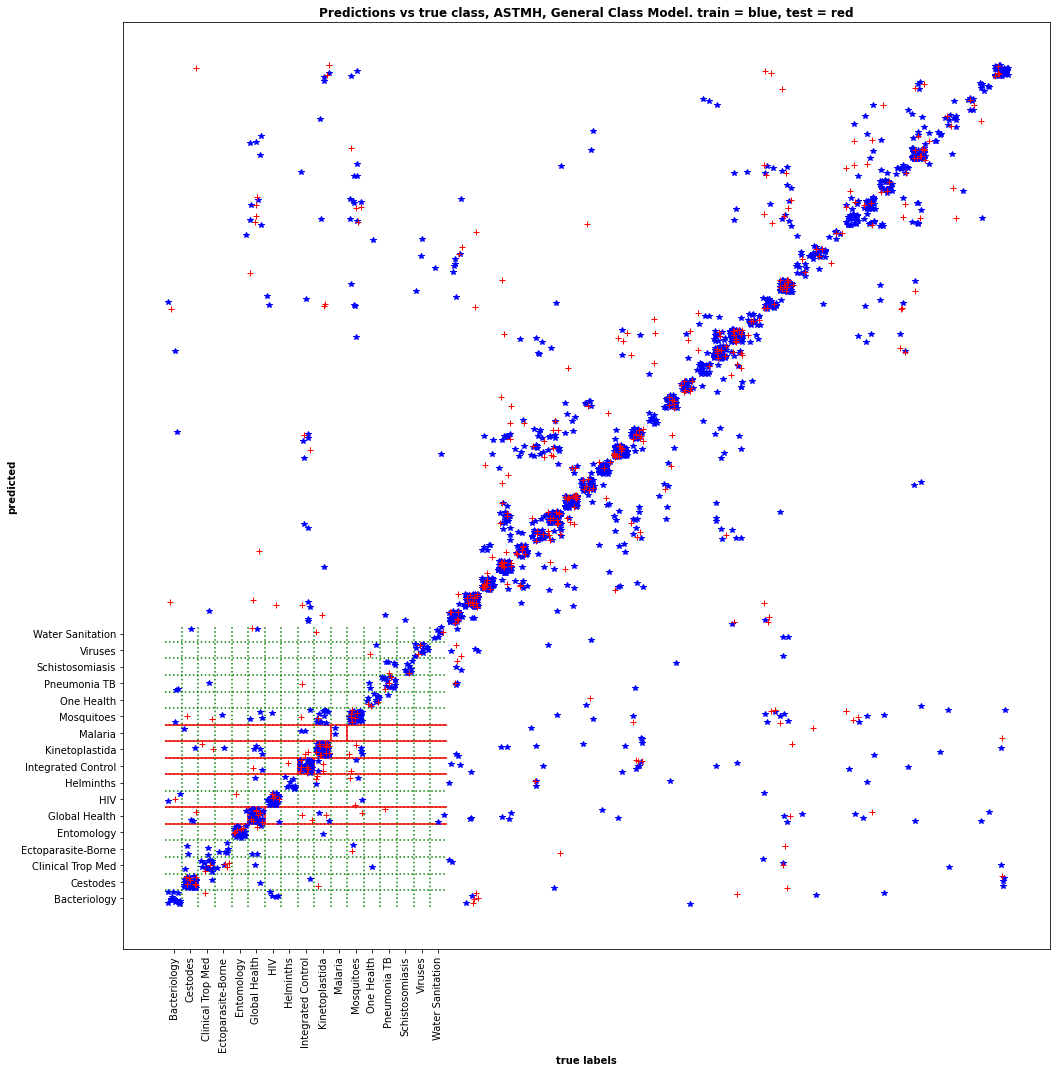

In [8]:
create17ClassConfusionMatrix_fn(train_preds['label'],
                                train_preds['prediction'],
                                val_preds['label'],
                                val_preds['prediction'],
                                titleStr='General Class Model'
                                )

In [9]:
def confusion_map(df, preds_col, cat_col='shortGenCat', normalize=False):
    fig, ax = plt.subplots(figsize=(8, 6))

    if not normalize:
        conf_matrix = confusion_matrix(df[cat_col], df[preds_col], labels=pd.unique(df[cat_col]))
        # Plotting the confusion matrix
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=pd.unique(df[cat_col]), yticklabels=pd.unique(df[cat_col]))
    else:
                # Calculate the normalized confusion matrix (by the number of elements in each true class)
        conf_matrix_normalized = confusion_matrix(df[cat_col],  df[preds_col], normalize='true', labels=pd.unique(df[cat_col]))
        # Plotting the normalized confusion matrix
        sns.heatmap(conf_matrix_normalized, annot=True, fmt='.0%', cmap='Blues', xticklabels=pd.unique(df[cat_col]), yticklabels=pd.unique(df[cat_col]))
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

In [10]:
label = np.array([1,1,2,2,3,3,4,4,5,5,6,6,7,7,8,8,9,9,10,10])
preds_classes = np.array([3,1,2,2,4,5,4,5,5,1,6,5,7,7,7,8,8,1,10,1])

In [11]:
label_idx = np.where(label == 5, 1, 0)
label_idx

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [12]:
pred_idx = np.where(preds_classes == 5, 1, 0)
pred_idx

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [13]:
pred_idx != label_idx

array([False, False, False, False, False,  True, False,  True, False,
        True, False,  True, False, False, False, False, False, False,
       False, False])

In [14]:
FNplusFP = np.sum(np.where(pred_idx != label_idx, 1, 0))

In [15]:
FNplusFP

4

In [16]:
green_classes = [5, 8, 10]
for c in green_classes:
    label_idx = np.where(label == c, 1, 0) # Find where there are green class labels
    pred_idx = np.where(preds_classes == c, 1, 0) # Find where there are green class predictions

    FNplusFP = np.sum(np.where(pred_idx != label_idx, 1, 0)) # Find FN plus FP 